In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully")

C:\Users\himan\AppData\Local\Temp\ipykernel_8112\1408128490.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries imported successfully


In [2]:
# Cell 2: Load Raw Dataset
raw_data_path = Path("../data/raw/zomato_delivery_raw.csv")

if not raw_data_path.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {raw_data_path}. "
        "Please run scripts/download_dataset.py first."
    )

# Load without any transformations
df_raw = pd.read_csv(raw_data_path)

print("=" * 70)
print("RAW DATASET LOADED")
print("=" * 70)
print(f"\nShape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nMemory usage: {df_raw.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

RAW DATASET LOADED

Shape: 38,964 rows × 22 columns

Memory usage: 31.46 MB


In [3]:
# Cell 3: Initial Schema Inspection
print("=" * 70)
print("COLUMN TYPES AND SAMPLE VALUES")
print("=" * 70)

schema_info = []
for col in df_raw.columns:
    dtype = str(df_raw[col].dtype)
    non_null = df_raw[col].notna().sum()
    null_count = df_raw[col].isna().sum()
    null_pct = (null_count / len(df_raw)) * 100
    unique_vals = df_raw[col].nunique()
    
    # Get sample value
    sample = df_raw[col].dropna().iloc[0] if non_null > 0 else "N/A"
    
    schema_info.append({
        'Column': col,
        'Type': dtype,
        'Non-Null': non_null,
        'Null': null_count,
        'Null %': f"{null_pct:.2f}%",
        'Unique': unique_vals,
        'Sample': str(sample)[:50]
    })

schema_df = pd.DataFrame(schema_info)
print(schema_df.to_string(index=False))

COLUMN TYPES AND SAMPLE VALUES
                     Column    Type  Non-Null  Null Null %  Unique             Sample
                         ID  object     38964     0  0.00%   38964             0xcdcd
         Delivery_person_ID  object     38964     0  0.00%    1170      DEHRES17DEL01
        Delivery_person_Age float64     37945  1019  2.62%      20               36.0
    Delivery_person_Ratings float64     37909  1055  2.71%      26                4.2
        Restaurant_latitude float64     38964     0  0.00%     388          30.327968
       Restaurant_longitude float64     38964     0  0.00%     388          78.046106
 Delivery_location_latitude float64     38964     0  0.00%    4352          30.397968
Delivery_location_longitude float64     38964     0  0.00%    4352          78.116106
                 Order_Date  object     38964     0  0.00%      44         12-02-2022
                Time_Orderd  object     38129   835  2.14%     176              21:55
          Time_Order_pi

In [4]:
# Cell 4: Missing Values Analysis
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Percent', ascending=False)

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("\nColumns with missing values:")
    print(missing_df)
    
    # Visualize missing values
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df['Missing_Percent'].plot(kind='bar', ax=ax)
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values detected")

MISSING VALUES ANALYSIS

Columns with missing values:
                         Missing_Count  Missing_Percent
Delivery_person_Ratings           1055             2.71
Delivery_person_Age               1019             2.62
Time_Orderd                        835             2.14


<Figure size 1200x600 with 1 Axes>

In [5]:
# Cell 5: Duplicate Records Check
print("=" * 70)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 70)

# Check for exact duplicates
exact_duplicates = df_raw.duplicated().sum()
print(f"\nExact duplicate rows: {exact_duplicates:,}")
print(f"Percentage: {(exact_duplicates / len(df_raw) * 100):.2f}%")

# Check for duplicates based on key columns
key_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd']
if all(col in df_raw.columns for col in key_cols):
    key_duplicates = df_raw.duplicated(subset=key_cols).sum()
    print(f"\nDuplicates based on key columns {key_cols}: {key_duplicates:,}")

DUPLICATE RECORDS ANALYSIS

Exact duplicate rows: 0
Percentage: 0.00%

Duplicates based on key columns ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd']: 0


In [6]:
# Cell 6: Numerical Column Analysis
print("=" * 70)
print("NUMERICAL COLUMNS STATISTICS")
print("=" * 70)

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 0:
    print("\nDescriptive statistics:")
    print(df_raw[numeric_cols].describe())
    
    # Check for potential issues
    print("\n" + "=" * 70)
    print("POTENTIAL DATA QUALITY ISSUES")
    print("=" * 70)
    
    for col in numeric_cols:
        print(f"\n{col}:")
        
        # Check for negative values where they shouldn't exist
        if col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken (min)']:
            negative_count = (df_raw[col] < 0).sum()
            if negative_count > 0:
                print(f"  ⚠ {negative_count} negative values found")
        
        # Check for zero values
        zero_count = (df_raw[col] == 0).sum()
        if zero_count > 0:
            print(f"  ⚠ {zero_count} zero values found")
        
        # Check for extreme values
        q99 = df_raw[col].quantile(0.99)
        q01 = df_raw[col].quantile(0.01)
        iqr = q99 - q01
        outliers = ((df_raw[col] > q99 + 1.5 * iqr) | (df_raw[col] < q01 - 1.5 * iqr)).sum()
        if outliers > 0:
            print(f"  ⚠ {outliers} potential outliers detected")

NUMERICAL COLUMNS STATISTICS

Descriptive statistics:
       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count             37945.00                 37909.00             38964.00   
mean                 29.61                     4.63                18.92   
std                   5.76                     0.32                 5.46   
min                  20.00                     2.50                 9.96   
25%                  25.00                     4.50                12.99   
50%                  30.00                     4.70                19.07   
75%                  35.00                     4.90                22.75   
max                  39.00                     5.00                30.91   

       Restaurant_longitude  Delivery_location_latitude  \
count              38964.00                    38964.00   
mean                  76.91                       18.98   
std                    3.50                        5.46   
min                   72.

In [7]:
# Cell 7: Categorical Column Analysis
print("=" * 70)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 70)

categorical_cols = df_raw.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df_raw[col].nunique()}")
    print(f"  Top 5 values:")
    
    value_counts = df_raw[col].value_counts().head(5)
    for val, count in value_counts.items():
        pct = (count / len(df_raw)) * 100
        print(f"    - {val}: {count:,} ({pct:.2f}%)")
    
    # Check for whitespace issues
    if df_raw[col].dtype == 'object':
        whitespace_issues = df_raw[col].str.contains(r'^\s|\s$|^\s+$', regex=True, na=False).sum()
        if whitespace_issues > 0:
            print(f"  ⚠ {whitespace_issues} values with leading/trailing whitespace")

CATEGORICAL COLUMNS ANALYSIS

ID:
  Unique values: 38964
  Top 5 values:
    - 0xcdcd: 1 (0.00%)
    - 0xddf5: 1 (0.00%)
    - 0x7965: 1 (0.00%)
    - 0xbd91: 1 (0.00%)
    - 0x533c: 1 (0.00%)

Delivery_person_ID:
  Unique values: 1170
  Top 5 values:
    - HYDRES04DEL02: 64 (0.16%)
    - JAPRES14DEL02: 63 (0.16%)
    - RANCHIRES16DEL01: 63 (0.16%)
    - COIMBRES010DEL02: 63 (0.16%)
    - VADRES11DEL02: 63 (0.16%)

Order_Date:
  Unique values: 44
  Top 5 values:
    - 15-03-2022: 1,031 (2.65%)
    - 03-04-2022: 1,016 (2.61%)
    - 09-03-2022: 1,013 (2.60%)
    - 13-03-2022: 1,008 (2.59%)
    - 05-04-2022: 1,007 (2.58%)

Time_Orderd:
  Unique values: 176
  Top 5 values:
    - 17:55: 407 (1.04%)
    - 21:55: 402 (1.03%)
    - 19:50: 401 (1.03%)
    - 21:15: 399 (1.02%)
    - 18:35: 396 (1.02%)

Time_Order_picked:
  Unique values: 193
  Top 5 values:
    - 21:30: 430 (1.10%)
    - 18:25: 396 (1.02%)
    - 18:45: 396 (1.02%)
    - 18:05: 394 (1.01%)
    - 21:45: 392 (1.01%)

Weather_condit

In [8]:
# Cell 8: Coordinate Validation
print("=" * 70)
print("GEOGRAPHIC COORDINATES VALIDATION")
print("=" * 70)

coord_cols = [
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude'
]

if all(col in df_raw.columns for col in coord_cols):
    print("\nCoordinate ranges:")
    for col in coord_cols:
        min_val = df_raw[col].min()
        max_val = df_raw[col].max()
        zero_count = (df_raw[col] == 0).sum()
        
        print(f"\n{col}:")
        print(f"  Min: {min_val:.6f}")
        print(f"  Max: {max_val:.6f}")
        print(f"  Zero values: {zero_count}")
        
        # Check for valid ranges
        if 'latitude' in col:
            invalid = ((df_raw[col] < -90) | (df_raw[col] > 90)).sum()
            if invalid > 0:
                print(f"  ⚠ {invalid} values outside valid latitude range [-90, 90]")
        elif 'longitude' in col:
            invalid = ((df_raw[col] < -180) | (df_raw[col] > 180)).sum()
            if invalid > 0:
                print(f"  ⚠ {invalid} values outside valid longitude range [-180, 180]")

GEOGRAPHIC COORDINATES VALIDATION

Coordinate ranges:

Restaurant_latitude:
  Min: 9.957144
  Max: 30.914057
  Zero values: 0

Restaurant_longitude:
  Min: 72.768726
  Max: 88.433452
  Zero values: 0

Delivery_location_latitude:
  Min: 9.967144
  Max: 31.054057
  Zero values: 0

Delivery_location_longitude:
  Min: 72.778726
  Max: 88.563452
  Zero values: 0


In [9]:
# Cell 9: Timestamp Analysis
print("=" * 70)
print("TIMESTAMP AND DATE ANALYSIS")
print("=" * 70)

# Check Order_Date
if 'Order_Date' in df_raw.columns:
    print("\nOrder_Date:")
    print(f"  Format sample: {df_raw['Order_Date'].iloc[0]}")
    
    # Try to parse dates
    try:
        dates = pd.to_datetime(df_raw['Order_Date'], errors='coerce')
        valid_dates = dates.notna().sum()
        invalid_dates = dates.isna().sum()
        
        print(f"  Valid dates: {valid_dates:,}")
        print(f"  Invalid dates: {invalid_dates:,}")
        
        if valid_dates > 0:
            print(f"  Date range: {dates.min()} to {dates.max()}")
            print(f"  Days covered: {(dates.max() - dates.min()).days + 1}")
    except Exception as e:
        print(f"  ⚠ Error parsing dates: {e}")

# Check time columns
time_cols = ['Time_Orderd', 'Time_Order_picked']
for col in time_cols:
    if col in df_raw.columns:
        print(f"\n{col}:")
        print(f"  Format sample: {df_raw[col].iloc[0]}")
        missing = df_raw[col].isna().sum()
        print(f"  Missing values: {missing:,}")

TIMESTAMP AND DATE ANALYSIS

Order_Date:
  Format sample: 12-02-2022
  Valid dates: 18,155
  Invalid dates: 20,809
  Date range: 2022-01-03 00:00:00 to 2022-12-03 00:00:00
  Days covered: 335

Time_Orderd:
  Format sample: 21:55
  Missing values: 835

Time_Order_picked:
  Format sample: 22:10
  Missing values: 0


DELIVERY TIME ANALYSIS

Delivery time statistics:
  Mean: 26.58 minutes
  Median: 26.00 minutes
  Std Dev: 9.34 minutes
  Min: 10.00 minutes
  Max: 54.00 minutes

Potential issues:
  Deliveries < 5 min: 0
  Deliveries > 120 min: 0
  Zero or negative: 0


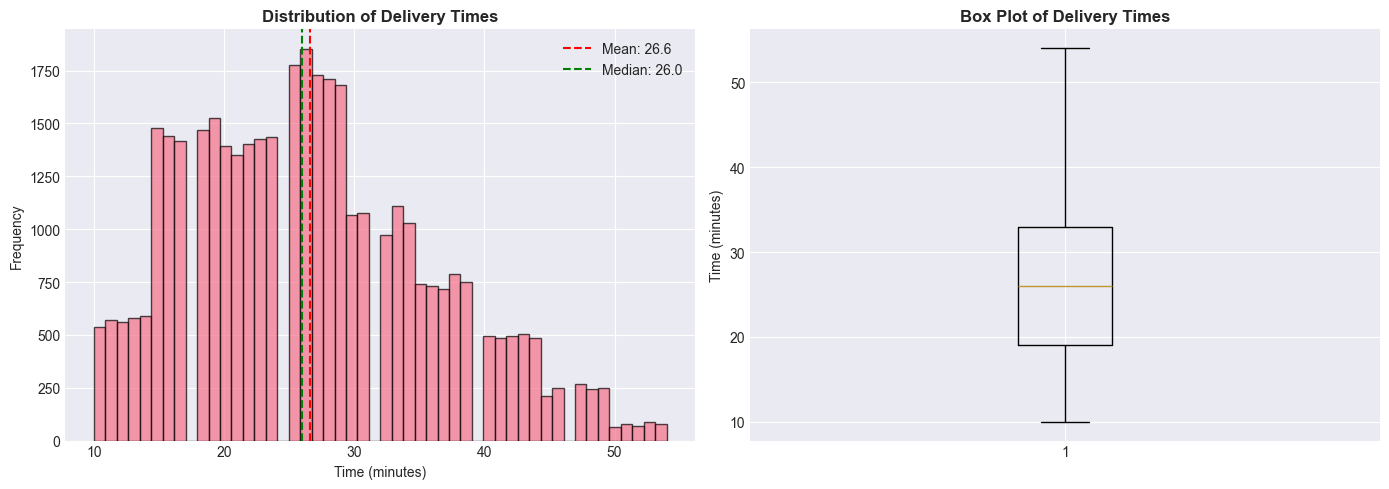

In [10]:
# Cell 10: Delivery Time Analysis
print("=" * 70)
print("DELIVERY TIME ANALYSIS")
print("=" * 70)

if 'Time_taken (min)' in df_raw.columns:
    delivery_time = df_raw['Time_taken (min)']
    
    print(f"\nDelivery time statistics:")
    print(f"  Mean: {delivery_time.mean():.2f} minutes")
    print(f"  Median: {delivery_time.median():.2f} minutes")
    print(f"  Std Dev: {delivery_time.std():.2f} minutes")
    print(f"  Min: {delivery_time.min():.2f} minutes")
    print(f"  Max: {delivery_time.max():.2f} minutes")
    
    # Check for unrealistic values
    print(f"\nPotential issues:")
    
    # Very short deliveries (< 5 minutes)
    very_short = (delivery_time < 5).sum()
    print(f"  Deliveries < 5 min: {very_short:,}")
    
    # Very long deliveries (> 120 minutes)
    very_long = (delivery_time > 120).sum()
    print(f"  Deliveries > 120 min: {very_long:,}")
    
    # Zero or negative
    invalid = (delivery_time <= 0).sum()
    print(f"  Zero or negative: {invalid:,}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(delivery_time, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Delivery Times', fontweight='bold')
    axes[0].set_xlabel('Time (minutes)')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(delivery_time.mean(), color='red', linestyle='--', label=f'Mean: {delivery_time.mean():.1f}')
    axes[0].axvline(delivery_time.median(), color='green', linestyle='--', label=f'Median: {delivery_time.median():.1f}')
    axes[0].legend()
    
    # Box plot
    axes[1].boxplot(delivery_time, vert=True)
    axes[1].set_title('Box Plot of Delivery Times', fontweight='bold')
    axes[1].set_ylabel('Time (minutes)')
    
    plt.tight_layout()
    plt.show()

In [11]:
# Cell 11: Data Quality Summary Report
print("=" * 70)
print("DATA QUALITY SUMMARY REPORT")
print("=" * 70)

issues = []

# Missing values
total_missing = df_raw.isnull().sum().sum()
if total_missing > 0:
    issues.append(f"Missing values: {total_missing:,} total cells")

# Duplicates
duplicates = df_raw.duplicated().sum()
if duplicates > 0:
    issues.append(f"Duplicate rows: {duplicates:,}")

# Check specific issues
if 'Time_taken (min)' in df_raw.columns:
    invalid_time = (df_raw['Time_taken (min)'] <= 0).sum()
    if invalid_time > 0:
        issues.append(f"Invalid delivery times (≤0): {invalid_time:,}")

# Coordinate issues
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 
              'Delivery_location_latitude', 'Delivery_location_longitude']
if all(col in df_raw.columns for col in coord_cols):
    zero_coords = sum((df_raw[col] == 0).sum() for col in coord_cols)
    if zero_coords > 0:
        issues.append(f"Zero coordinate values: {zero_coords:,}")

print(f"\nTotal rows: {len(df_raw):,}")
print(f"Total columns: {len(df_raw.columns)}")
print(f"\nIssues detected: {len(issues)}")

if issues:
    print("\nCritical issues:")
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")
else:
    print("\n✓ No critical issues detected in initial scan")

print("\n" + "=" * 70)
print("NEXT STEPS")
print("=" * 70)
print("1. Review detailed findings in subsequent notebooks")
print("2. Document all cleaning decisions in docs/data_quality.md")
print("3. Proceed to data cleaning (02_data_cleaning.ipynb)")

DATA QUALITY SUMMARY REPORT

Total rows: 38,964
Total columns: 22

Issues detected: 1

Critical issues:
  1. Missing values: 2,909 total cells

NEXT STEPS
1. Review detailed findings in subsequent notebooks
2. Document all cleaning decisions in docs/data_quality.md
3. Proceed to data cleaning (02_data_cleaning.ipynb)
